# Cell 0: Kiểm tra GPU và CUDA

In [1]:
import sys
import torch

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    device_id = torch.cuda.current_device()
    props = torch.cuda.get_device_properties(device_id)
    print("GPU:", torch.cuda.get_device_name(device_id))
    print("VRAM GB:", round(props.total_memory / 1024**3, 2))
    print("cuDNN:", torch.backends.cudnn.version())
    x = torch.randn(512, 512, device="cuda")
    y = x @ x
    print("Tensor test:", y.shape, y.device)
else:
    print("Device: CPU")

Python: 3.13.1
PyTorch: 2.12.0+cu126
CUDA available: True
CUDA version: 12.6
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM GB: 4.0
cuDNN: 91002
Tensor test: torch.Size([512, 512]) cuda:0


# Cell 1: Import thư viện cần thiết

In [2]:
import os, json, time, random, shutil, hashlib
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchinfo import summary

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_DIR / "data" / "raw" / "Dataset-Meat"
SPLIT_DIR = PROJECT_DIR / "data" / "splits"
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
CKPT_DIR = ARTIFACT_DIR / "checkpoints"
LOG_DIR = ARTIFACT_DIR / "logs"
FIG_DIR = ARTIFACT_DIR / "figures"
MODEL_DIR = ARTIFACT_DIR / "models"

for p in [CKPT_DIR, LOG_DIR, FIG_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project:", PROJECT_DIR)
print("Raw dataset:", RAW_DIR)
print("Raw exists:", RAW_DIR.exists())
print("Classes:", sorted([p.name for p in RAW_DIR.iterdir()]) if RAW_DIR.exists() else "NOT FOUND")
print("Device:", device)

Project: d:\Documents\HK2 2025-26 KHDL (Y3) Ky 6\TH DL\Meat Classify
Raw dataset: d:\Documents\HK2 2025-26 KHDL (Y3) Ky 6\TH DL\Meat Classify\data\raw\Dataset-Meat
Raw exists: True
Classes: ['Fresh', 'Spoiled']
Device: cuda


# Cell 2: Load dataset

In [3]:
classes = ["Fresh", "Spoiled"]
exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

rows, bad = [], []

for cls in classes:
    files = [p for p in (RAW_DIR / cls).rglob("*") if p.suffix.lower() in exts]
    for p in tqdm(files, desc=cls):
        try:
            with Image.open(p) as img:
                img.verify()
            rows.append({"path": str(p), "label": cls, "size_kb": round(p.stat().st_size / 1024, 2)})
        except Exception as e:
            bad.append({"path": str(p), "label": cls, "error": str(e)})

df = pd.DataFrame(rows)
bad_df = pd.DataFrame(bad)

Fresh:   0%|          | 0/484 [00:00<?, ?it/s]

Spoiled: 100%|██████████| 289/289 [00:00<00:00, 7043.68it/s]


# Cell 3: EDA dữ liệu ảnh

Reading image sizes:   0%|          | 0/773 [00:00<?, ?it/s]

Reading image sizes: 100%|██████████| 773/773 [00:00<00:00, 8530.93it/s]


Total images: 773
Total classes: 2
Classes: ['Fresh', 'Spoiled']
Imbalance ratio: 1.67


,count,percent
label,,
Fresh,484,62.61
Spoiled,289,37.39


,count,mean,std,min,25%,50%,75%,max
width,773.0,256.172057,79.945643,110.00,225.00,259.00,279.00,1500.00
height,773.0,209.578266,88.634054,111.00,180.00,194.00,225.00,2048.00
pixels,773.0,57807.302717,121548.298435,12210.00,50246.00,50370.00,50508.00,2795520.00
size_kb,773.0,11.785757,33.728135,2.91,6.66,8.66,10.44,568.74


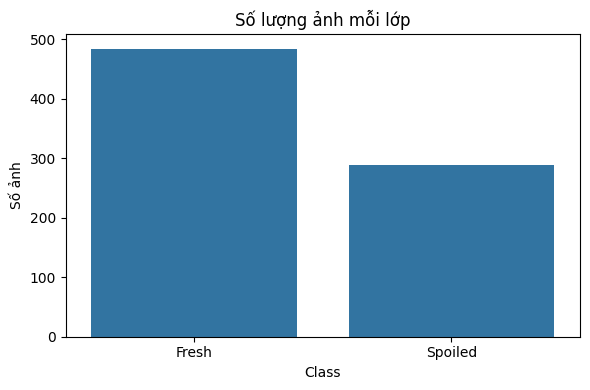

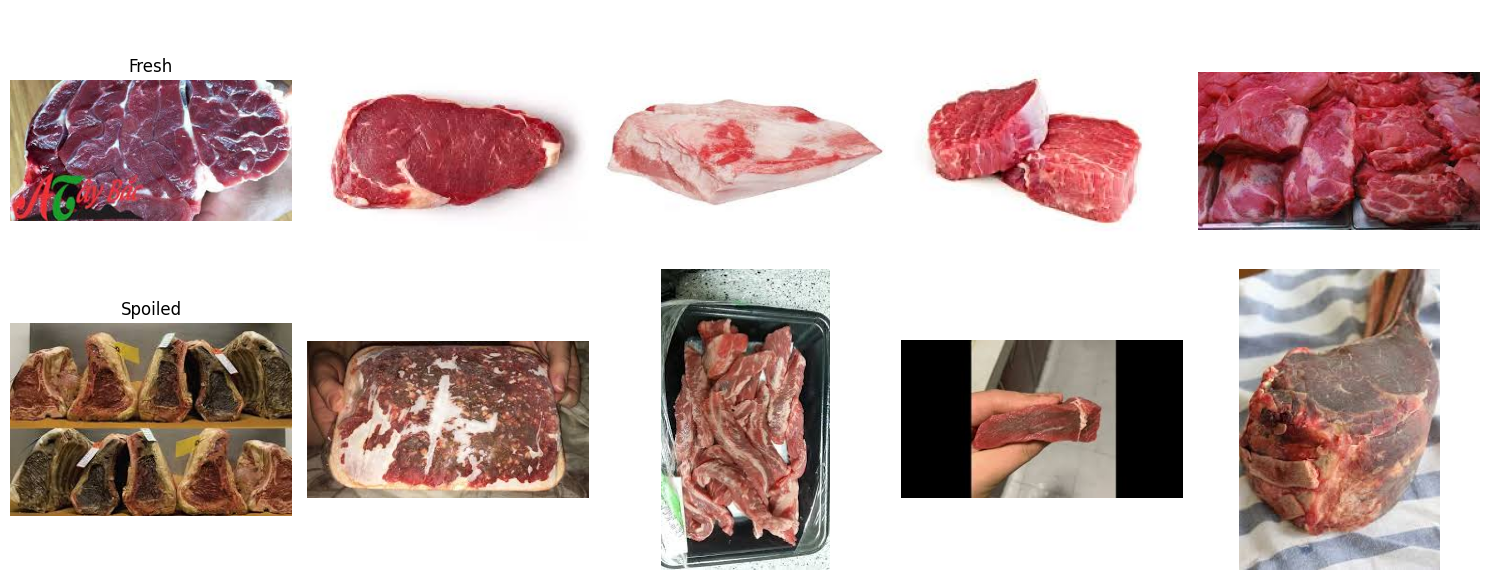

In [4]:
dims = []

for p in tqdm(df["path"], desc="Reading image sizes"):
    with Image.open(p) as img:
        dims.append(img.size)

df[["width", "height"]] = pd.DataFrame(dims, index=df.index)
df["pixels"] = df["width"] * df["height"]

class_count = df["label"].value_counts()
eda = pd.DataFrame({
    "count": class_count,
    "percent": (class_count / len(df) * 100).round(2)
})

print("Total images:", len(df))
print("Total classes:", df["label"].nunique())
print("Classes:", sorted(df["label"].unique()))
print("Imbalance ratio:", round(class_count.max() / class_count.min(), 2))
display(eda)
display(df[["width", "height", "pixels", "size_kb"]].describe().T)

plt.figure(figsize=(6, 4))
sns.barplot(x=class_count.index, y=class_count.values)
plt.title("Số lượng ảnh mỗi lớp")
plt.xlabel("Class")
plt.ylabel("Số ảnh")
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=200)
plt.show()
n = 5
fig, axes = plt.subplots(len(classes), n, figsize=(15, 3 * len(classes)))

for i, cls in enumerate(classes):
    paths = df[df["label"] == cls]["path"].sample(min(n, (df["label"] == cls).sum()), random_state=seed).tolist()
    for j in range(n):
        ax = axes[i, j] if len(classes) > 1 else axes[j]
        ax.axis("off")
        if j < len(paths):
            ax.imshow(Image.open(paths[j]).convert("RGB"))
            ax.set_title(cls if j == 0 else "")

plt.tight_layout()
plt.savefig(FIG_DIR / "random_samples_by_class.png", dpi=200)
plt.show()

# Cell 4: Tìm và xóa ảnh trùng lặp

In [5]:
DUP_DIR = PROJECT_DIR / "data" / "duplicates"
DUP_DIR.mkdir(parents=True, exist_ok=True)

def md5_file(p):
    h = hashlib.md5()
    with open(p, "rb") as f:
        h.update(f.read())
    return h.hexdigest()

df["md5"] = [md5_file(p) for p in tqdm(df["path"], desc="Hashing images")]

dup_df = df[df.duplicated("md5", keep="first")].copy()
dup_df.to_csv(LOG_DIR / "duplicate_images.csv", index=False)

for i, r in tqdm(dup_df.iterrows(), total=len(dup_df), desc="Moving duplicates"):
    src = Path(r["path"])
    dst_dir = DUP_DIR / r["label"]
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst = dst_dir / f"{src.stem}_{i}{src.suffix}"
    if src.exists():
        shutil.move(str(src), str(dst))

df = df[~df["path"].isin(dup_df["path"])].reset_index(drop=True)
df.to_csv(LOG_DIR / "clean_metadata_after_duplicates.csv", index=False)

print("Duplicate images:", len(dup_df))
print("Remaining images:", len(df))
print(df["label"].value_counts())
display(dup_df.head())

Hashing images: 100%|██████████| 773/773 [00:00<00:00, 8486.72it/s]
Moving duplicates: 0it [00:00, ?it/s]

Duplicate images: 0
Remaining images: 773
label
Fresh      484
Spoiled    289
Name: count, dtype: int64


,path,label,size_kb,width,height,pixels,md5


# Cell 5: Chia train/val/test 70/15/15

test: 100%|██████████| 116/116 [00:00<00:00, 413.67it/s]


label,Fresh,Spoiled,total
split,,,
train,339,202,541
val,72,44,116
test,73,43,116


<Figure size 700x400 with 0 Axes>

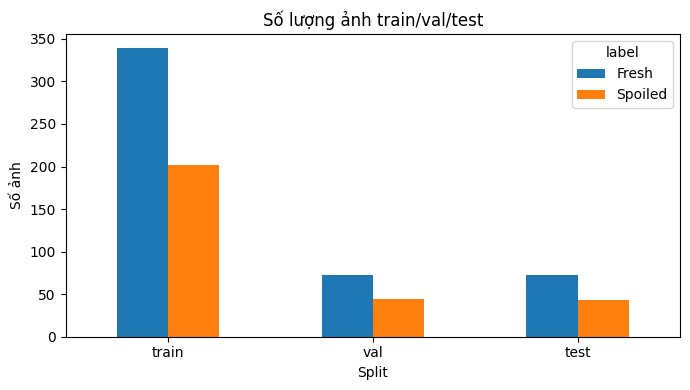

Total: 773


In [6]:
for split in ["train", "val", "test"]:
    for cls in classes:
        d = SPLIT_DIR / split / cls
        if d.exists():
            shutil.rmtree(d)
        d.mkdir(parents=True, exist_ok=True)

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=seed)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=seed)

split_map = {"train": train_df, "val": val_df, "test": test_df}

for split, part in split_map.items():
    part = part.reset_index(drop=True)
    part.to_csv(LOG_DIR / f"{split}_metadata.csv", index=False)
    for _, r in tqdm(part.iterrows(), total=len(part), desc=split):
        src = Path(r["path"])
        dst = SPLIT_DIR / split / r["label"] / src.name
        shutil.copy2(src, dst)

split_summary = pd.concat([part.assign(split=split) for split, part in split_map.items()])
split_count = pd.crosstab(split_summary["split"], split_summary["label"]).loc[["train", "val", "test"]]
split_count["total"] = split_count.sum(axis=1)

display(split_count)

plt.figure(figsize=(7, 4))
split_count[classes].plot(kind="bar", figsize=(7, 4))
plt.title("Số lượng ảnh train/val/test")
plt.xlabel("Split")
plt.ylabel("Số ảnh")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "split_distribution.png", dpi=200)
plt.show()

print("Total:", split_count["total"].sum())

# Cell 6: Resize và chuẩn hóa ảnh

In [7]:
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 0

stat_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

stat_ds = datasets.ImageFolder(SPLIT_DIR / "train", transform=stat_tf)
stat_loader = DataLoader(stat_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

mean = torch.zeros(3)
std = torch.zeros(3)

for x, _ in tqdm(stat_loader, desc="Computing mean/std"):
    mean += x.mean(dim=(0, 2, 3)) * x.size(0)
    std += x.std(dim=(0, 2, 3)) * x.size(0)

mean = (mean / len(stat_ds)).tolist()
std = (std / len(stat_ds)).tolist()

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_ds_base = datasets.ImageFolder(SPLIT_DIR / "train", transform=eval_tf)
val_ds = datasets.ImageFolder(SPLIT_DIR / "val", transform=eval_tf)
test_ds = datasets.ImageFolder(SPLIT_DIR / "test", transform=eval_tf)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

class_to_idx = train_ds_base.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

with open(LOG_DIR / "class_to_idx.json", "w", encoding="utf-8") as f:
    json.dump(class_to_idx, f, ensure_ascii=False, indent=2)

with open(LOG_DIR / "mean_std.json", "w", encoding="utf-8") as f:
    json.dump({"mean": mean, "std": std}, f, indent=2)

x, y = next(iter(val_loader))

print("Mean:", mean)
print("Std:", std)
print("Classes:", class_to_idx)
print("Train/Val/Test:", len(train_ds_base), len(val_ds), len(test_ds))
print("Val batch:", x.shape, y.shape)
print("Device:", device)

Computing mean/std: 100%|██████████| 9/9 [00:01<00:00,  5.85it/s]


Mean: [0.6798871159553528, 0.53843754529953, 0.5153191089630127]
Std: [0.2357582300901413, 0.2844722867012024, 0.2881786525249481]
Classes: {'Fresh': 0, 'Spoiled': 1}
Train/Val/Test: 541 116 116
Val batch: torch.Size([64, 3, 224, 224]) torch.Size([64])
Device: cuda


# Cell 7: Data augmentation cho tập train

Train augmented: 541
Classes: {'Fresh': 0, 'Spoiled': 1}


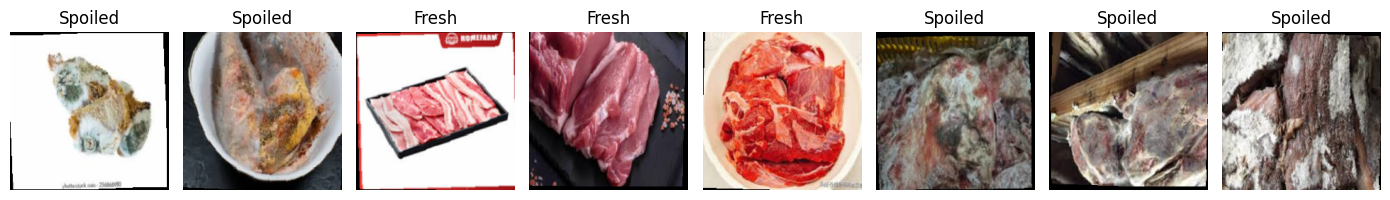

In [8]:
train_tf = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.94, 1.0), ratio=(0.97, 1.03)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(3),
    transforms.RandomAffine(degrees=0, translate=(0.02, 0.02), scale=(0.97, 1.03), shear=1),
    transforms.RandomPerspective(distortion_scale=0.03, p=0.08),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_ds = datasets.ImageFolder(SPLIT_DIR / "train", transform=train_tf)

def show_batch(ds, n=8):
    loader = DataLoader(ds, batch_size=n, shuffle=True, num_workers=0)
    x, y = next(iter(loader))
    x = x.permute(0, 2, 3, 1).numpy()
    y = y.numpy()
    m, s = np.array(mean), np.array(std)
    x = np.clip(x * s + m, 0, 1)

    plt.figure(figsize=(14, 4))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(x[i])
        plt.title(idx_to_class[int(y[i])])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

print("Train augmented:", len(train_ds))
print("Classes:", train_ds.class_to_idx)
show_batch(train_ds)

# Cell 8: Gợi ý siêu tham số huấn luyện (cân bằng dữ liệu, siêu tham số)

In [9]:
BATCH_SIZE = 64

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

targets = torch.tensor(train_ds.targets)
counts = torch.bincount(targets, minlength=len(classes)).float()
class_weights = (counts.sum() / (len(classes) * counts)).to(device)

CFG = {
    "img_size": 224,
    "batch_size": BATCH_SIZE,
    "epochs": 45,
    "patience": 10,
    "lr": 8e-5,
    "min_lr": 1e-6,
    "weight_decay": 1e-4,
    "label_smoothing": 0.01,
    "grad_clip": 1.0,
    "use_amp": True,
    "num_classes": 2,
    "metric": "val_acc",
    "save": ["last", "best"]
}

with open(LOG_DIR / "train_config.json", "w", encoding="utf-8") as f:
    json.dump(CFG, f, indent=2)

print("Train counts:", dict(zip(classes, counts.int().tolist())))
print("Class weights:", dict(zip(classes, class_weights.detach().cpu().round(decimals=4).tolist())))
print("Sampler: None")
print(json.dumps(CFG, indent=2))

Train counts: {'Fresh': 339, 'Spoiled': 202}
Class weights: {'Fresh': 0.7979000210762024, 'Spoiled': 1.3391000032424927}
Sampler: None
{
  "img_size": 224,
  "batch_size": 64,
  "epochs": 45,
  "patience": 10,
  "lr": 8e-05,
  "min_lr": 1e-06,
  "weight_decay": 0.0001,
  "label_smoothing": 0.01,
  "grad_clip": 1.0,
  "use_amp": true,
  "num_classes": 2,
  "metric": "val_acc",
  "save": [
    "last",
    "best"
  ]
}


# Cell 9: Xây dựng mô hình CNN từ đầu

In [10]:
for p in list(CKPT_DIR.glob("advanced_cnn*")) + list(CKPT_DIR.glob("cbam_tinyvit*")):
    p.unlink(missing_ok=True)

for p in list(LOG_DIR.glob("advanced_cnn*")) + list(LOG_DIR.glob("cbam_tinyvit*")):
    p.unlink(missing_ok=True)

for p in list(MODEL_DIR.glob("advanced_cnn*")) + list(MODEL_DIR.glob("cbam_tinyvit*")):
    p.unlink(missing_ok=True)

class ConvBN(nn.Module):
    def __init__(self, c1, c2, k=3, s=1, p=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c1, c2, k, s, p, bias=False),
            nn.BatchNorm2d(c2),
            nn.SiLU(inplace=True)
        )
    def forward(self, x):
        return self.net(x)

class BasicCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            ConvBN(3, 32), nn.MaxPool2d(2),
            ConvBN(32, 64), nn.MaxPool2d(2),
            ConvBN(64, 128), nn.MaxPool2d(2),
            nn.Dropout2d(0.05),
            ConvBN(128, 192), nn.MaxPool2d(2),
            nn.Dropout2d(0.08),
            ConvBN(192, 256)
        )
        self.cam_layer = self.features[-1]
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.head(self.features(x))

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

models_dict = {"basic_cnn": BasicCNN(CFG["num_classes"]).to(device)}

dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)

for name, model in models_dict.items():
    model.eval()
    with torch.no_grad():
        out = model(dummy)
    print(name, "| params:", f"{count_params(model):,}", "| output:", tuple(out.shape))

basic_cnn | params: 758,434 | output: (2, 2)


In [11]:
from torchinfo import summary as torch_summary

def list_activations(model):
    return sorted({m.__class__.__name__ for m in model.modules() if isinstance(m, (nn.ReLU, nn.SiLU, nn.GELU, nn.Sigmoid, nn.Softmax))})

name, model = "basic_cnn", models_dict["basic_cnn"]

model_info = torch_summary(
    model,
    input_size=(1, 3, IMG_SIZE, IMG_SIZE),
    col_names=["input_size", "output_size", "num_params"],
    depth=3,
    verbose=0
)

print("=" * 90)
print(name)
print("Params:", f"{count_params(model):,}")
print("Activations:", list_activations(model))
print(model_info)

with open(LOG_DIR / "basic_cnn_summary.txt", "w", encoding="utf-8") as f:
    f.write(str(model_info))

basic_cnn
Params: 758,434
Activations: ['SiLU']
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
BasicCNN                                 [1, 3, 224, 224]          [1, 2]                    --
├─Sequential: 1-1                        [1, 3, 224, 224]          [1, 256, 14, 14]          442,880
│    └─ConvBN: 2-1                       [1, 3, 224, 224]          [1, 32, 224, 224]         --
│    │    └─Sequential: 3-1              [1, 3, 224, 224]          [1, 32, 224, 224]         928
│    └─MaxPool2d: 2-2                    [1, 32, 224, 224]         [1, 32, 112, 112]         --
│    └─ConvBN: 2-3                       [1, 32, 112, 112]         [1, 64, 112, 112]         --
│    │    └─Sequential: 3-2              [1, 32, 112, 112]         [1, 64, 112, 112]         18,560
│    └─MaxPool2d: 2-4                    [1, 64, 112, 112]         [1, 64, 56, 56]           --
│    └─ConvBN: 2-5                       [1, 64, 56, 56]           [1, 12

# Cell 10: Huấn luyện CNN

In [12]:
import math

name = "basic_cnn"
model = BasicCNN(CFG["num_classes"]).to(device)
models_dict = {name: model}

for p in [CKPT_DIR / f"{name}_best.pt", CKPT_DIR / f"{name}_last.pt", LOG_DIR / f"{name}_history.csv"]:
    p.unlink(missing_ok=True)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=CFG["label_smoothing"])
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
scaler = torch.amp.GradScaler("cuda", enabled=CFG["use_amp"] and device.type == "cuda")

warmup_epochs = 5

def lr_lambda(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    t = (epoch - warmup_epochs) / max(1, CFG["epochs"] - warmup_epochs)
    return max(CFG["min_lr"] / CFG["lr"], 0.5 * (1 + math.cos(math.pi * t)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def run_epoch(model, loader, train=False):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0

    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)

        with torch.set_grad_enabled(train):
            with torch.amp.autocast("cuda", enabled=CFG["use_amp"] and device.type == "cuda"):
                out = model(x)
                loss = criterion(out, y)

            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
                scaler.step(optimizer)
                scaler.update()

        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += x.size(0)

    return total_loss / total, correct / total

best_acc, best_loss, wait, history = 0, float("inf"), 0, []

for epoch in range(1, CFG["epochs"] + 1):
    t0 = time.time()

    train_loss, train_acc = run_epoch(model, train_loader, train=True)
    val_loss, val_acc = run_epoch(model, val_loader, train=False)
    lr = optimizer.param_groups[0]["lr"]

    row = {
        "epoch": epoch,
        "train_acc": train_acc,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "lr": lr,
        "time_sec": round(time.time() - t0, 2)
    }

    history.append(row)
    history_df = pd.DataFrame(history)
    history_df.to_csv(LOG_DIR / f"{name}_history.csv", index=False)

    ckpt = {
        "model": model.state_dict(),
        "cfg": CFG,
        "class_to_idx": class_to_idx,
        "mean": mean,
        "std": std,
        "epoch": epoch,
        "val_acc": val_acc,
        "val_loss": val_loss
    }

    torch.save(ckpt, CKPT_DIR / f"{name}_last.pt")

    improved = (val_acc > best_acc) or (val_acc == best_acc and val_loss < best_loss)

    print(f"{name} | epoch {epoch:02d}/{CFG['epochs']} | train_acc={train_acc:.4f} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

    if improved:
        best_acc, best_loss, wait = val_acc, val_loss, 0
        torch.save(ckpt, CKPT_DIR / f"{name}_best.pt")
        print(f"Save best model | best val_acc = {best_acc:.4f}")
    else:
        wait += 1

    scheduler.step()

    if wait >= CFG["patience"]:
        break

best_idx = history_df.sort_values(["val_acc", "val_loss"], ascending=[False, True]).index[0]

result_df = pd.DataFrame([{
    "model": name,
    "best_epoch": int(history_df.loc[best_idx, "epoch"]),
    "best_val_acc": history_df.loc[best_idx, "val_acc"],
    "best_val_loss": history_df.loc[best_idx, "val_loss"],
    "last_val_acc": history_df["val_acc"].iloc[-1]
}])

result_df.to_csv(LOG_DIR / "train_summary.csv", index=False)
display(result_df)

basic_cnn | epoch 01/45 | train_acc=0.6895 | train_loss=0.6383 | val_loss=0.6998 | val_acc=0.3793
Save best model | best val_acc = 0.3793


basic_cnn | epoch 02/45 | train_acc=0.7911 | train_loss=0.4899 | val_loss=0.6826 | val_acc=0.4224
Save best model | best val_acc = 0.4224


basic_cnn | epoch 03/45 | train_acc=0.8189 | train_loss=0.3848 | val_loss=0.5332 | val_acc=0.7414
Save best model | best val_acc = 0.7414


basic_cnn | epoch 04/45 | train_acc=0.8392 | train_loss=0.3512 | val_loss=0.3748 | val_acc=0.8362
Save best model | best val_acc = 0.8362


basic_cnn | epoch 05/45 | train_acc=0.8669 | train_loss=0.3198 | val_loss=0.3007 | val_acc=0.8879
Save best model | best val_acc = 0.8879


...

basic_cnn | epoch 30/45 | train_acc=0.9279 | train_loss=0.2196 | val_loss=0.2067 | val_acc=0.9224


basic_cnn | epoch 31/45 | train_acc=0.9187 | train_loss=0.2251 | val_loss=0.2050 | val_acc=0.9483


basic_cnn | epoch 32/45 | train_acc=0.9316 | train_loss=0.2154 | val_loss=0.2072 | val_acc=0.9397


basic_cnn | epoch 33/45 | train_acc=0.9187 | train_loss=0.2259 | val_loss=0.2061 | val_acc=0.9138


,model,best_epoch,best_val_acc,best_val_loss,last_val_acc
0,basic_cnn,23,0.956897,0.211321,0.913793


# Cell 11: Vẽ biểu đồ Train/Val Loss và Accuracy

Train acc: 0.9187
Val acc: 0.9138
Best val acc: 0.9569
Best epoch: 23


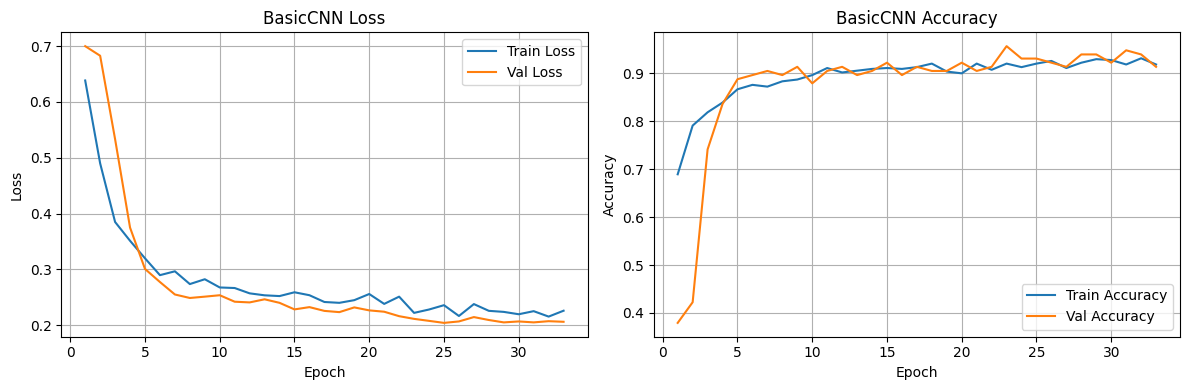

In [24]:
history_df = pd.read_csv(LOG_DIR / "basic_cnn_history.csv")

best_row = history_df.loc[history_df["val_acc"].idxmax()]
last_row = history_df.iloc[-1]

print("Train acc:", round(last_row["train_acc"], 4))
print("Val acc:", round(last_row["val_acc"], 4))
print("Best val acc:", round(best_row["val_acc"], 4))
print("Best epoch:", int(best_row["epoch"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
axes[0].set_title("BasicCNN Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
axes[1].plot(history_df["epoch"], history_df["val_acc"], label="Val Accuracy")
axes[1].set_title("BasicCNN Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(FIG_DIR / "basic_cnn_loss_accuracy.png", dpi=200)
plt.show()

# Cell 12: Đánh giá trên tập test

Testing: 100%|██████████| 2/2 [00:01<00:00,  1.02it/s]

Test accuracy: 0.9052

              precision    recall  f1-score   support

       Fresh       0.91      0.95      0.93        73
     Spoiled       0.90      0.84      0.87        43

    accuracy                           0.91       116
   macro avg       0.90      0.89      0.90       116
weighted avg       0.90      0.91      0.90       116



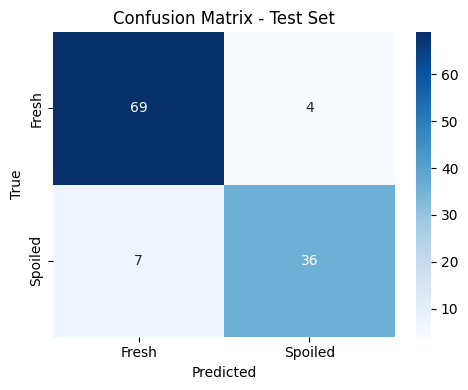

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

ckpt = torch.load(CKPT_DIR / "basic_cnn_best.pt", map_location=device, weights_only=False)

model = BasicCNN(CFG["num_classes"]).to(device)
model.load_state_dict(ckpt["model"])
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for x, y in tqdm(test_loader, desc="Testing"):
        x = x.to(device)
        out = model(x)
        pred = out.argmax(1).cpu().numpy()
        y_true.extend(y.numpy())
        y_pred.extend(pred)

acc = accuracy_score(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=classes)
cm = confusion_matrix(y_true, y_pred)
print("Test accuracy:", round(acc, 4))
print()
print(report)

pd.DataFrame({"y_true": y_true, "y_pred": y_pred}).to_csv(LOG_DIR / "test_predictions.csv", index=False)
pd.DataFrame(cm, index=classes, columns=classes).to_csv(LOG_DIR / "test_confusion_matrix.csv")
pd.DataFrame(classification_report(y_true, y_pred, target_names=classes, output_dict=True)).T.to_csv(LOG_DIR / "test_classification_report.csv")

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(FIG_DIR / "test_confusion_matrix.png", dpi=200)
plt.show()

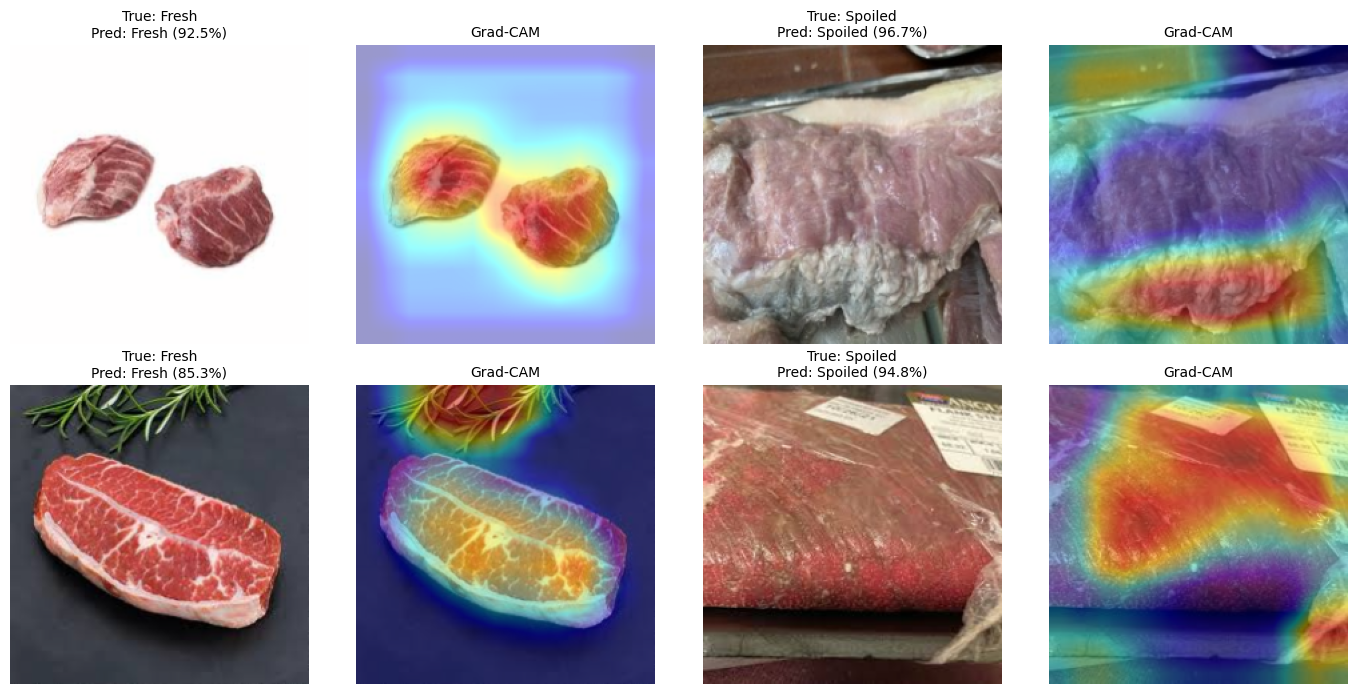

In [19]:
ckpt = torch.load(CKPT_DIR / "basic_cnn_best.pt", map_location=device, weights_only=False)

model = BasicCNN(CFG["num_classes"]).to(device)
model.load_state_dict(ckpt["model"])
model.eval()

class GradCAM:
    def __init__(self, model, layer):
        self.model = model
        self.a, self.g = None, None
        self.h1 = layer.register_forward_hook(self.f_hook)
        self.h2 = layer.register_full_backward_hook(self.b_hook)

    def f_hook(self, m, i, o):
        self.a = o

    def b_hook(self, m, gi, go):
        self.g = go[0]

    def __call__(self, x, target):
        self.model.zero_grad(set_to_none=True)
        out = self.model(x)
        out[:, target].sum().backward()
        w = self.g.mean(dim=(2, 3), keepdim=True)
        cam = (w * self.a).sum(1).relu()
        cam = F.interpolate(cam[:, None], size=x.shape[-2:], mode="bilinear", align_corners=False)[0, 0]
        cam = cam.detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

    def close(self):
        self.h1.remove()
        self.h2.remove()

def denorm_img(x):
    img = x.permute(1, 2, 0).cpu().numpy()
    img = np.clip(img * np.array(std) + np.array(mean), 0, 1)
    return img

def overlay_cam(img, cam):
    heat = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB) / 255
    return np.clip(0.6 * img + 0.4 * heat, 0, 1)

picked = []
for cls_name in classes:
    cls_id = class_to_idx[cls_name]
    idxs = [i for i, y in enumerate(test_ds.targets) if y == cls_id]
    picked += random.sample(idxs, min(2, len(idxs)))

random.shuffle(picked)

cam_tool = GradCAM(model, model.cam_layer)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()

for k, idx in enumerate(picked[:4]):
    x, y = test_ds[idx]
    x_in = x.unsqueeze(0).to(device)

    with torch.no_grad():
        prob = torch.softmax(model(x_in), dim=1)[0].cpu().numpy()

    pred = int(prob.argmax())
    conf = prob[pred]
    cam = cam_tool(x_in, pred)

    img = denorm_img(x)
    over = overlay_cam(img, cam)

    axes[2 * k].imshow(img)
    axes[2 * k].set_title(f"True: {idx_to_class[y]}\nPred: {idx_to_class[pred]} ({conf:.1%})", fontsize=10)
    axes[2 * k].axis("off")

    axes[2 * k + 1].imshow(over)
    axes[2 * k + 1].set_title("Grad-CAM", fontsize=10)
    axes[2 * k + 1].axis("off")

cam_tool.close()

plt.tight_layout()
plt.savefig(FIG_DIR / "random_test_gradcam.png", dpi=200)
plt.show()

# Cell 13: Lưu model

In [26]:
FINAL_MODEL_PATH = MODEL_DIR / "basic_cnn_final.pt"
FINAL_META_PATH = MODEL_DIR / "basic_cnn_metadata.json"

ckpt = torch.load(CKPT_DIR / "basic_cnn_best.pt", map_location=device, weights_only=False)

model = BasicCNN(CFG["num_classes"]).to(device)
model.load_state_dict(ckpt["model"])
model.eval()

final_package = {
    "model_state_dict": model.state_dict(),
    "model_name": "basic_cnn",
    "architecture": "BasicCNN",
    "class_to_idx": class_to_idx,
    "idx_to_class": idx_to_class,
    "mean": mean,
    "std": std,
    "img_size": IMG_SIZE,
    "num_classes": CFG["num_classes"],
    "best_epoch": ckpt["epoch"],
    "best_val_acc": ckpt.get("val_acc", None),
    "best_val_loss": ckpt.get("val_loss", None)
}

torch.save(final_package, FINAL_MODEL_PATH)

metadata = {
    "model_file": str(FINAL_MODEL_PATH),
    "model_name": "basic_cnn",
    "architecture": "BasicCNN",
    "class_to_idx": class_to_idx,
    "idx_to_class": idx_to_class,
    "mean": mean,
    "std": std,
    "img_size": IMG_SIZE,
    "num_classes": CFG["num_classes"],
    "best_epoch": ckpt["epoch"],
    "best_val_acc": ckpt.get("val_acc", None),
    "best_val_loss": ckpt.get("val_loss", None)
}

with open(FINAL_META_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Saved final model:", FINAL_MODEL_PATH)
print("Saved metadata:", FINAL_META_PATH)
print("Model size MB:", round(FINAL_MODEL_PATH.stat().st_size / 1024**2, 2))

Saved final model: d:\Documents\HK2 2025-26 KHDL (Y3) Ky 6\TH DL\Meat Classify\artifacts\models\basic_cnn_final.pt
Saved metadata: d:\Documents\HK2 2025-26 KHDL (Y3) Ky 6\TH DL\Meat Classify\artifacts\models\basic_cnn_metadata.json
Model size MB: 2.91


# Cell 14: Tổng hợp quá trình thực nghiệm

In [28]:
exp_records = [
    {
        "exp": "Exp 01",
        "model": "BasicCNN / AdvancedCNN / CBAM-TinyViT",
        "split": "80/10/10",
        "augmentation": "Resize 256, RandomResizedCrop 224 scale=(0.85,1.0), HorizontalFlip p=0.5, Rotation 10, ColorJitter brightness=0.12 contrast=0.12 saturation=0.08 hue=0.02, GaussianBlur p=0.15",
        "balance": "Class weight",
        "loss": "Weighted CrossEntropy",
        "scheduler": "ReduceLROnPlateau",
        "params": "389K / 3.65M / 965K",
        "best_val_acc": 0.9189
    },
    {
        "exp": "Exp 02",
        "model": "BasicCNN",
        "split": "70/15/15",
        "augmentation": "Resize 256, RandomResizedCrop 224 scale=(0.85,1.0), HorizontalFlip p=0.5, Rotation 10, ColorJitter brightness=0.12 contrast=0.12 saturation=0.08 hue=0.02, GaussianBlur p=0.15",
        "balance": "Class weight",
        "loss": "Weighted CrossEntropy",
        "scheduler": "CosineAnnealingLR",
        "params": "758K",
        "best_val_acc": 0.9286
    },
    {
        "exp": "Exp 03",
        "model": "BasicCNN residual",
        "split": "70/15/15",
        "augmentation": "Resize 240, RandomResizedCrop 224 scale=(0.90,1.0), HorizontalFlip p=0.5, VerticalFlip p=0.2, Rotation 5, RandomAffine translate=(0.03,0.03) scale=(0.95,1.05) shear=3, RandomPerspective distortion=0.05 p=0.15",
        "balance": "Class weight",
        "loss": "Weighted CrossEntropy",
        "scheduler": "Warmup 5 epochs + Cosine",
        "params": "~2.8M",
        "best_val_acc": 0.9554
    },
    {
        "exp": "Exp 04",
        "model": "BasicCNN + EMA",
        "split": "70/15/15",
        "augmentation": "Resize 240, RandomResizedCrop 224 scale=(0.90,1.0), HorizontalFlip p=0.5, VerticalFlip p=0.2, Rotation 5, RandomAffine translate=(0.03,0.03) scale=(0.95,1.05) shear=3, RandomPerspective distortion=0.05 p=0.15",
        "balance": "Class weight",
        "loss": "Weighted CrossEntropy",
        "scheduler": "Warmup 5 epochs + Cosine",
        "params": "758K",
        "best_val_acc": 0.9286
    },
    {
        "exp": "Exp 05",
        "model": "CNN residual + SE attention",
        "split": "70/15/15",
        "augmentation": "Resize 240, RandomResizedCrop 224 scale=(0.90,1.0), HorizontalFlip p=0.5, VerticalFlip p=0.2, Rotation 5, RandomAffine translate=(0.03,0.03) scale=(0.95,1.05) shear=3, RandomPerspective distortion=0.05 p=0.15",
        "balance": "WeightedRandomSampler + class weight",
        "loss": "Focal Loss gamma=1.5 smoothing=0.02",
        "scheduler": "Warmup 5 epochs + Cosine",
        "params": "2.81M",
        "best_val_acc": 0.9286
    },
    {
        "exp": "Exp 06 - Final",
        "model": "BasicCNN",
        "split": "70/15/15",
        "augmentation": "Resize 240, RandomResizedCrop 224 scale=(0.94,1.0) ratio=(0.97,1.03), HorizontalFlip p=0.5, VerticalFlip p=0.1, Rotation 3, RandomAffine translate=(0.02,0.02) scale=(0.97,1.03) shear=1, RandomPerspective distortion=0.03 p=0.08",
        "balance": "Class weight",
        "loss": "Weighted CrossEntropy smoothing=0.02",
        "scheduler": "Warmup 5 epochs + Cosine",
        "params": "758K",
        "best_val_acc": 0.9464
    }
]

exp_df = pd.DataFrame(exp_records)

summary_path = PROJECT_DIR / "reports" / "experiment_summary.csv"
summary_path.parent.mkdir(parents=True, exist_ok=True)
exp_df.to_csv(summary_path, index=False, encoding="utf-8-sig")

display(exp_df)

print("Tổng số thực nghiệm:", len(exp_df))
print("Mô hình final:", "BasicCNN")
print("Best validation accuracy final:", 0.9464)
print("Đã lưu bảng tổng hợp:", summary_path)

,exp,model,split,augmentation,balance,loss,scheduler,params,best_val_acc
0,Exp 01,BasicCNN / AdvancedCNN / CBAM-TinyViT,80/10/10,"Resize 256, RandomResizedCrop 224 scale=(0.85,...",Class weight,Weighted CrossEntropy,ReduceLROnPlateau,389K / 3.65M / 965K,0.9189
1,Exp 02,BasicCNN,70/15/15,"Resize 256, RandomResizedCrop 224 scale=(0.85,...",Class weight,Weighted CrossEntropy,CosineAnnealingLR,758K,0.9286
2,Exp 03,BasicCNN residual,70/15/15,"Resize 240, RandomResizedCrop 224 scale=(0.90,...",Class weight,Weighted CrossEntropy,Warmup 5 epochs + Cosine,~2.8M,0.9554
3,Exp 04,BasicCNN + EMA,70/15/15,"Resize 240, RandomResizedCrop 224 scale=(0.90,...",Class weight,Weighted CrossEntropy,Warmup 5 epochs + Cosine,758K,0.9286
4,Exp 05,CNN residual + SE attention,70/15/15,"Resize 240, RandomResizedCrop 224 scale=(0.90,...",WeightedRandomSampler + class weight,Focal Loss gamma=1.5 smoothing=0.02,Warmup 5 epochs + Cosine,2.81M,0.9286
5,Exp 06 - Final,BasicCNN,70/15/15,"Resize 240, RandomResizedCrop 224 scale=(0.94,...",Class weight,Weighted CrossEntropy smoothing=0.02,Warmup 5 epochs + Cosine,758K,0.9464


Tổng số thực nghiệm: 6
Mô hình final: BasicCNN
Best validation accuracy final: 0.9464
Đã lưu bảng tổng hợp: d:\Documents\HK2 2025-26 KHDL (Y3) Ky 6\TH DL\Meat Classify\reports\experiment_summary.csv


# Cell 15: Đánh giá model tốt nhất trên dataset công khai

Exception in thread Thread-6 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\threading.py", line 1041, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "C:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\threading.py", line 992, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1609, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "C:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in position 207: character maps to <undefined>


Public dataset: crowww/meat-quality-assessment-based-on-deep-learning
Tổng số ảnh: 1896
Số class: 2
Số ảnh mỗi class:


,count
label,
Fresh,948
Spoiled,948


Public testing: 100%|██████████| 30/30 [00:28<00:00,  1.04it/s]

Model hiện tại: basic_cnn | test_acc = 0.6319 | params = 758,434

Số mẫu đúng / tổng số mẫu mỗi class:


,class,correct/total,correct,total,class_acc
0,Fresh,948/948,948,948,1.0000
1,Spoiled,250/948,250,948,0.2637


Accuracy: 0.6319

Classification Report:
              precision    recall  f1-score   support

       Fresh       0.58      1.00      0.73       948
     Spoiled       1.00      0.26      0.42       948

    accuracy                           0.63      1896
   macro avg       0.79      0.63      0.57      1896
weighted avg       0.79      0.63      0.57      1896



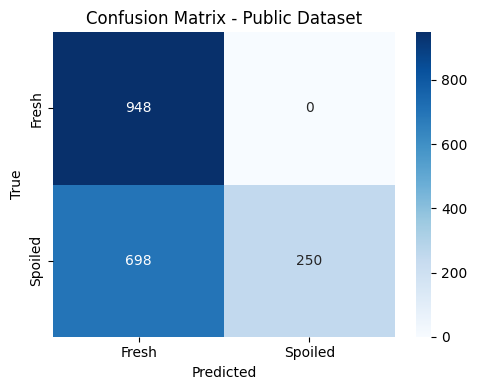

In [7]:
import subprocess, sys
from pathlib import Path
from PIL import Image, ImageOps

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODEL_DIR = PROJECT_DIR / "artifacts" / "models"
LOG_DIR = PROJECT_DIR / "artifacts" / "logs"
FIG_DIR = PROJECT_DIR / "artifacts" / "figures"

LOG_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ConvBN(nn.Module):
    def __init__(self, c1, c2, k=3, s=1, p=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c1, c2, k, s, p, bias=False),
            nn.BatchNorm2d(c2),
            nn.SiLU(inplace=True)
        )
    def forward(self, x):
        return self.net(x)

class BasicCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            ConvBN(3, 32), nn.MaxPool2d(2),
            ConvBN(32, 64), nn.MaxPool2d(2),
            ConvBN(64, 128), nn.MaxPool2d(2),
            nn.Dropout2d(0.05),
            ConvBN(128, 192), nn.MaxPool2d(2),
            nn.Dropout2d(0.08),
            ConvBN(192, 256)
        )
        self.cam_layer = self.features[-1]
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.head(self.features(x))

PUBLIC_DATASET = "crowww/meat-quality-assessment-based-on-deep-learning"
PUBLIC_DIR = PROJECT_DIR / "data" / "public_eval" / "meat_quality_assessment"
PUBLIC_DIR.mkdir(parents=True, exist_ok=True)

if not any(PUBLIC_DIR.rglob("*")):
    kaggle_cmd = Path(sys.executable).parent / "kaggle.exe"

    if not kaggle_cmd.exists():
        kaggle_cmd = "kaggle"

    res = subprocess.run(
        [str(kaggle_cmd), "datasets", "download", "-d", PUBLIC_DATASET, "-p", str(PUBLIC_DIR), "--unzip"],
        capture_output=True,
        text=True
    )

if res.returncode != 0:
    print("STDOUT:", res.stdout)
    print("STDERR:", res.stderr)
    raise RuntimeError("Kaggle download failed")

final_path = MODEL_DIR / "basic_cnn_final.pt"
package = torch.load(final_path, map_location=device, weights_only=False)

class_to_idx = {k: int(v) for k, v in package["class_to_idx"].items()}
idx_to_class = {int(k): v for k, v in package["idx_to_class"].items()}
classes = [idx_to_class[i] for i in range(len(idx_to_class))]

IMG_SIZE = int(package["img_size"])
BATCH_SIZE = 64
NUM_WORKERS = 0
mean = package["mean"]
std = package["std"]

model = BasicCNN(package["num_classes"]).to(device)
model.load_state_dict(package["model_state_dict"])
model.eval()

param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

def infer_public_label(p):
    text = " ".join([x.lower() for x in p.parts])
    if "fresh" in text:
        return "Fresh"
    if any(k in text for k in ["spoiled", "spoilt", "rotten", "stale"]):
        return "Spoiled"
    return None

exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
rows = []

for p in PUBLIC_DIR.rglob("*"):
    if p.suffix.lower() in exts:
        label = infer_public_label(p)
        if label in class_to_idx:
            rows.append({"path": str(p), "label": label})

public_df = pd.DataFrame(rows).drop_duplicates("path").reset_index(drop=True)

if len(public_df) == 0:
    raise RuntimeError(f"Không tìm thấy ảnh Fresh/Spoiled trong {PUBLIC_DIR}")

public_count = public_df["label"].value_counts().reindex(classes, fill_value=0)

print("Public dataset:", PUBLIC_DATASET)
print("Tổng số ảnh:", len(public_df))
print("Số class:", public_df["label"].nunique())
print("Số ảnh mỗi class:")
display(public_count.to_frame("count"))

class PublicMeatDataset(Dataset):
    def __init__(self, df, tf, class_to_idx):
        self.df = df.reset_index(drop=True)
        self.tf = tf
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(r["path"])
        img = ImageOps.exif_transpose(img).convert("RGB")
        return self.tf(img), self.class_to_idx[r["label"]]

public_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

public_ds = PublicMeatDataset(public_df, public_tf, class_to_idx)
public_loader = DataLoader(public_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

y_true, y_pred = [], []

with torch.no_grad():
    for x, y in tqdm(public_loader, desc="Public testing"):
        x = x.to(device)
        out = model(x)
        pred = out.argmax(1).cpu().numpy()
        y_true.extend(y.numpy())
        y_pred.extend(pred)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
report_text = classification_report(y_true, y_pred, target_names=classes, zero_division=0)
report_dict = classification_report(y_true, y_pred, target_names=classes, output_dict=True, zero_division=0)

per_class_rows = []

for i, cls in enumerate(classes):
    total = int(np.sum(y_true == i))
    correct = int(np.sum((y_true == i) & (y_pred == i)))
    per_class_rows.append({
        "class": cls,
        "correct/total": f"{correct}/{total}",
        "correct": correct,
        "total": total,
        "class_acc": round(correct / total, 4) if total else 0
    })

per_class_df = pd.DataFrame(per_class_rows)

print(f"Model hiện tại: {package.get('model_name', 'basic_cnn')} | test_acc = {acc:.4f} | params = {param_count:,}")
print("\nSố mẫu đúng / tổng số mẫu mỗi class:")
display(per_class_df)

print("Accuracy:", round(acc, 4))
print("\nClassification Report:")
print(report_text)

pd.DataFrame([{
    "model": package.get("model_name", "basic_cnn"),
    "public_dataset": PUBLIC_DATASET,
    "test_acc": acc,
    "params": param_count,
    "total_images": len(public_df),
    "num_classes": public_df["label"].nunique()
}]).to_csv(LOG_DIR / "public_dataset_model_summary.csv", index=False)

public_count.to_frame("count").to_csv(LOG_DIR / "public_dataset_class_count.csv")
per_class_df.to_csv(LOG_DIR / "public_dataset_per_class_correct.csv", index=False)
pd.DataFrame(report_dict).T.to_csv(LOG_DIR / "public_dataset_classification_report.csv")
pd.DataFrame(cm, index=classes, columns=classes).to_csv(LOG_DIR / "public_dataset_confusion_matrix.csv")

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix - Public Dataset")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(FIG_DIR / "public_dataset_confusion_matrix.png", dpi=200)
plt.show()

Collect probs: 100%|██████████| 15/15 [00:12<00:00,  1.22it/s]


Public val/test: 948 948
Best threshold from public_val: 0.05
Model hiện tại: basic_cnn | tuned_public_test_acc = 0.9177 | params = 758,434

So sánh threshold:


,setting,threshold,acc,macro_f1,balanced_acc,fresh_recall,spoiled_recall
0,Default threshold 0.50,0.50,0.640295,0.586837,0.640295,1.0,0.280591
1,Tuned threshold,0.05,0.917722,0.917161,0.917722,1.0,0.835443



Số mẫu đúng / tổng số mẫu mỗi class trên public_test:


,class,correct/total,correct,total,class_acc
0,Fresh,474/474,474,474,1.0000
1,Spoiled,396/474,396,474,0.8354


Accuracy: 0.9177

Classification Report:
              precision    recall  f1-score   support

       Fresh       0.86      1.00      0.92       474
     Spoiled       1.00      0.84      0.91       474

    accuracy                           0.92       948
   macro avg       0.93      0.92      0.92       948
weighted avg       0.93      0.92      0.92       948



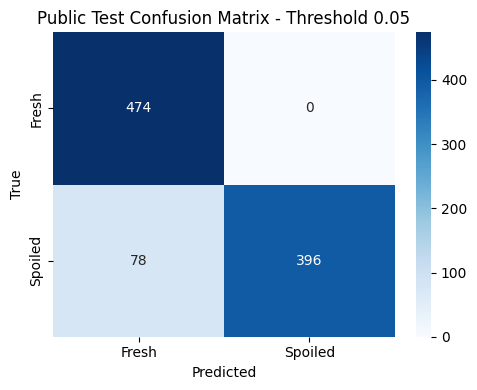

,threshold,acc,macro_f1,balanced_acc,fresh_recall,spoiled_recall
0,0.05,0.931435,0.931130,0.931435,0.99789,0.864979
1,0.06,0.908228,0.907484,0.908228,0.99789,0.818565
2,0.07,0.891350,0.890103,0.891350,0.99789,0.784810
3,0.08,0.874473,0.872531,0.874473,0.99789,0.751055
4,0.09,0.861814,0.859207,0.861814,0.99789,0.725738
5,0.10,0.851266,0.847998,0.851266,0.99789,0.704641
6,0.11,0.838608,0.834406,0.838608,0.99789,0.679325
7,0.12,0.827004,0.821800,0.827004,0.99789,0.656118
8,0.13,0.813291,0.806704,0.813291,0.99789,0.628692
9,0.14,0.803797,0.795942,0.803797,1.00000,0.607595


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, recall_score, classification_report, confusion_matrix

seed = globals().get("seed", 42)

public_val_df, public_test_df = train_test_split(
    public_df,
    test_size=0.5,
    stratify=public_df["label"],
    random_state=seed
)

public_val_ds = PublicMeatDataset(public_val_df, public_tf, class_to_idx)
public_test_ds = PublicMeatDataset(public_test_df, public_tf, class_to_idx)

public_val_loader = DataLoader(public_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
public_test_loader = DataLoader(public_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

fresh_id = class_to_idx["Fresh"]
spoiled_id = class_to_idx["Spoiled"]

def collect_probs(loader):
    ys, probs = [], []
    model.eval()
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Collect probs"):
            x = x.to(device)
            p = torch.softmax(model(x), dim=1).cpu().numpy()
            ys.extend(y.numpy())
            probs.extend(p)
    return np.array(ys), np.array(probs)

def pred_threshold(probs, th):
    pred = np.full(len(probs), fresh_id)
    pred[probs[:, spoiled_id] >= th] = spoiled_id
    return pred

def calc_metrics(y, pred):
    return {
        "acc": accuracy_score(y, pred),
        "macro_f1": f1_score(y, pred, average="macro", zero_division=0),
        "balanced_acc": balanced_accuracy_score(y, pred),
        "fresh_recall": recall_score(y, pred, labels=[fresh_id], average=None, zero_division=0)[0],
        "spoiled_recall": recall_score(y, pred, labels=[spoiled_id], average=None, zero_division=0)[0]
    }

val_y, val_probs = collect_probs(public_val_loader)
test_y, test_probs = collect_probs(public_test_loader)

rows = []
for th in np.arange(0.05, 0.96, 0.01):
    pred = pred_threshold(val_probs, th)
    m = calc_metrics(val_y, pred)
    rows.append({"threshold": round(float(th), 2), **m})

th_df = pd.DataFrame(rows)
best_row = th_df.sort_values(["macro_f1", "balanced_acc", "acc"], ascending=False).iloc[0]
best_th = float(best_row["threshold"])

default_pred = pred_threshold(test_probs, 0.50)
tuned_pred = pred_threshold(test_probs, best_th)

default_metrics = calc_metrics(test_y, default_pred)
tuned_metrics = calc_metrics(test_y, tuned_pred)

compare_df = pd.DataFrame([
    {"setting": "Default threshold 0.50", "threshold": 0.50, **default_metrics},
    {"setting": "Tuned threshold", "threshold": best_th, **tuned_metrics}
])

cm = confusion_matrix(test_y, tuned_pred, labels=[fresh_id, spoiled_id])
report_text = classification_report(test_y, tuned_pred, target_names=classes, zero_division=0)
report_dict = classification_report(test_y, tuned_pred, target_names=classes, output_dict=True, zero_division=0)

per_class = []
for i, cls in enumerate(classes):
    total = int(np.sum(test_y == i))
    correct = int(np.sum((test_y == i) & (tuned_pred == i)))
    per_class.append({
        "class": cls,
        "correct/total": f"{correct}/{total}",
        "correct": correct,
        "total": total,
        "class_acc": round(correct / total, 4) if total else 0
    })

per_class_df = pd.DataFrame(per_class)

print("Public val/test:", len(public_val_df), len(public_test_df))
print("Best threshold from public_val:", best_th)
print(f"Model hiện tại: {package.get('model_name', 'basic_cnn')} | tuned_public_test_acc = {tuned_metrics['acc']:.4f} | params = {param_count:,}")
print("\nSo sánh threshold:")
display(compare_df)

print("\nSố mẫu đúng / tổng số mẫu mỗi class trên public_test:")
display(per_class_df)

print("Accuracy:", round(tuned_metrics["acc"], 4))
print("\nClassification Report:")
print(report_text)

th_df.to_csv(LOG_DIR / "public_threshold_search_val.csv", index=False)
compare_df.to_csv(LOG_DIR / "public_threshold_compare_test.csv", index=False)
per_class_df.to_csv(LOG_DIR / "public_threshold_per_class_correct.csv", index=False)
pd.DataFrame(report_dict).T.to_csv(LOG_DIR / "public_threshold_classification_report.csv")
pd.DataFrame(cm, index=classes, columns=classes).to_csv(LOG_DIR / "public_threshold_confusion_matrix.csv")

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title(f"Public Test Confusion Matrix - Threshold {best_th}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(FIG_DIR / "public_threshold_confusion_matrix.png", dpi=200)
plt.show()

display(th_df.sort_values(["macro_f1", "balanced_acc"], ascending=False).head(10))